In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# K-Means Clustering
from sklearn.cluster import KMeans

In [2]:
# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Shape of dataset
print("Shape of Dataset:")
print(df.shape)

print("\n")

# Column names
print("Column Names:")
print(df.columns)

print("\n")

# Dataset information
print("Dataset Information:")
df.info()

Shape of Dataset:
(200, 5)


Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Check missing values
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
# Statistical summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
# Select features for clustering

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Display first 5 rows
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [7]:
# List to store WCSS values
wcss = []

# Calculate WCSS for K values from 1 to 10
for k in range(1, 11):

    # Create KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Train the model
    kmeans.fit(X)

    # Store WCSS value
    wcss.append(kmeans.inertia_)

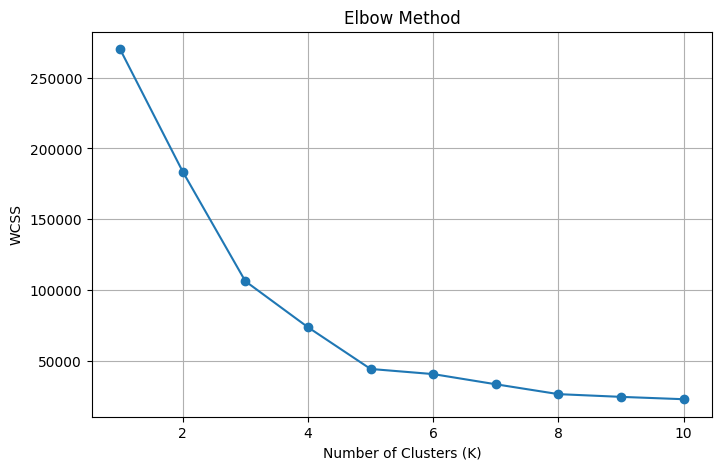

In [8]:
# Plot Elbow Method

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [9]:
# Print WCSS values

for i, value in enumerate(wcss, start=1):
    print("Clusters =", i, " WCSS =", round(value,2))

Clusters = 1  WCSS = 269981.28
Clusters = 2  WCSS = 183653.33
Clusters = 3  WCSS = 106348.37
Clusters = 4  WCSS = 73880.64
Clusters = 5  WCSS = 44448.46
Clusters = 6  WCSS = 40825.17
Clusters = 7  WCSS = 33642.58
Clusters = 8  WCSS = 26686.84
Clusters = 9  WCSS = 24766.47
Clusters = 10  WCSS = 23103.12


In [10]:
# Create the K-Means model
kmeans = KMeans(n_clusters=5, random_state=42)

# Train the model and assign clusters
clusters = kmeans.fit_predict(X)

print("Model trained successfully!")

Model trained successfully!


In [11]:
print(clusters)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [12]:
# Add cluster labels to the dataset
df["Cluster"] = clusters

# Display first 10 rows
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [13]:
# Count customers in each cluster
print(df["Cluster"].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [14]:
# Display customers in Cluster 0
cluster0 = df[df["Cluster"] == 0]

print(cluster0.head())

    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
43          44  Female   31                  39                      61   
46          47  Female   50                  40                      55   
47          48  Female   27                  40                      47   
48          49  Female   29                  40                      42   
49          50  Female   31                  40                      42   

    Cluster  
43        0  
46        0  
47        0  
48        0  
49        0  


In [15]:
# Display cluster centers
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


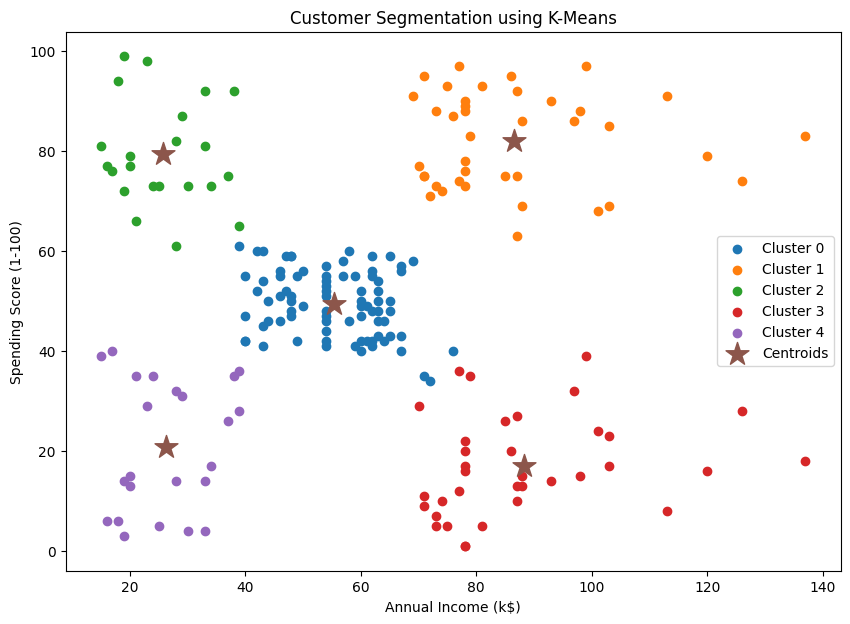

In [16]:
# Create figure
plt.figure(figsize=(10, 7))

# Plot each cluster separately
plt.scatter(
    X[clusters == 0]["Annual Income (k$)"],
    X[clusters == 0]["Spending Score (1-100)"],
    label="Cluster 0"
)

plt.scatter(
    X[clusters == 1]["Annual Income (k$)"],
    X[clusters == 1]["Spending Score (1-100)"],
    label="Cluster 1"
)

plt.scatter(
    X[clusters == 2]["Annual Income (k$)"],
    X[clusters == 2]["Spending Score (1-100)"],
    label="Cluster 2"
)

plt.scatter(
    X[clusters == 3]["Annual Income (k$)"],
    X[clusters == 3]["Spending Score (1-100)"],
    label="Cluster 3"
)

plt.scatter(
    X[clusters == 4]["Annual Income (k$)"],
    X[clusters == 4]["Spending Score (1-100)"],
    label="Cluster 4"
)

# Plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="*",
    s=300,
    label="Centroids"
)

# Labels
plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

In [17]:
# Display cluster centers

centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

print("Cluster Centers")
print(centers)

Cluster Centers
   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


In [18]:
print("Customer Cluster Interpretation")
print("--------------------------------")
print("Cluster 0 : Average Income - Average Spending")
print("Cluster 1 : High Income - High Spending")
print("Cluster 2 : Low Income - Low Spending")
print("Cluster 3 : Low Income - High Spending")
print("Cluster 4 : High Income - Low Spending")

Customer Cluster Interpretation
--------------------------------
Cluster 0 : Average Income - Average Spending
Cluster 1 : High Income - High Spending
Cluster 2 : Low Income - Low Spending
Cluster 3 : Low Income - High Spending
Cluster 4 : High Income - Low Spending


In [19]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
score = silhouette_score(X, clusters)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.554


In [20]:
import joblib

# Save the model
joblib.dump(kmeans, "kmeans_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [21]:
# Load the saved model
loaded_model = joblib.load("kmeans_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [22]:
# Predict cluster using loaded model
cluster = loaded_model.predict([[70, 75]])

print("Predicted Cluster:", cluster[0])

Predicted Cluster: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
